In [12]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn

from sklearn.datasets import make_regression
from torch.utils.data import Dataset, DataLoader, random_split

torch.manual_seed(42)
np.random.seed(42)


## 1 Автоматическое дифференцирование в `torch`
1.1 Воспользовавшись классами `Neuron` и `SquaredLoss` из задачи 4.1 из предыдущего задания и автоматическим дифференцированием, которое предоставляет `torch`, решить задачу регрессии. Для оптимизации использовать стохастический градиетный спуск.


In [13]:
X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

class Neuron:
  def __init__(self, n_inputs):
    self.weights = torch.randn(n_inputs, requires_grad=True)
    self.bias = torch.randn(1, requires_grad=True)

  def forward(self, inputs):
    return inputs @ self.weights + self.bias

class SquaredLoss:
  def forward(self, y_pred, y_true):
    return (y_pred - y_true) ** 2

neuron = Neuron(X.shape[1])
loss_fn = SquaredLoss()
learning_rate = 0.01
losses_11 = []

for epoch in range(60):
  epoch_loss = 0.0
  for x_example, y_example in zip(X, y):
    y_pred = neuron.forward(x_example)
    loss = loss_fn.forward(y_pred, y_example)
    loss.backward()

    with torch.no_grad():
      neuron.weights -= learning_rate * neuron.weights.grad
      neuron.bias -= learning_rate * neuron.bias.grad

    neuron.weights.grad.zero_()
    neuron.bias.grad.zero_()
    epoch_loss += loss.item()

  losses_11.append(epoch_loss / len(X))

print('1.1 final loss:', losses_11[-1])
print('1.1 learned weights:', neuron.weights.detach())
print('1.1 learned bias:', neuron.bias.detach())


1.1 final loss: 7.437994842263152e-10
1.1 learned weights: tensor([ 5.6375, 86.4722, 27.3407, 41.4819])
1.1 learned bias: tensor([0.5000])


1.2 Воспользовавшись классами `Linear` и `MSELoss` из задачи 1.4 и 3.1 из предыдущего задания, `ReLU` из 2.1 из предыдущего задания и автоматическим дифференцированием, которое предоставляет `torch`, решить задачу регрессии. Для оптимизации использовать пакетный градиентный спуск. Вывести график функции потерь в зависимости от номера эпохи. Вывести на одном графике исходные данные и предсказанные значения.


1.2 final loss: 0.08607633411884308


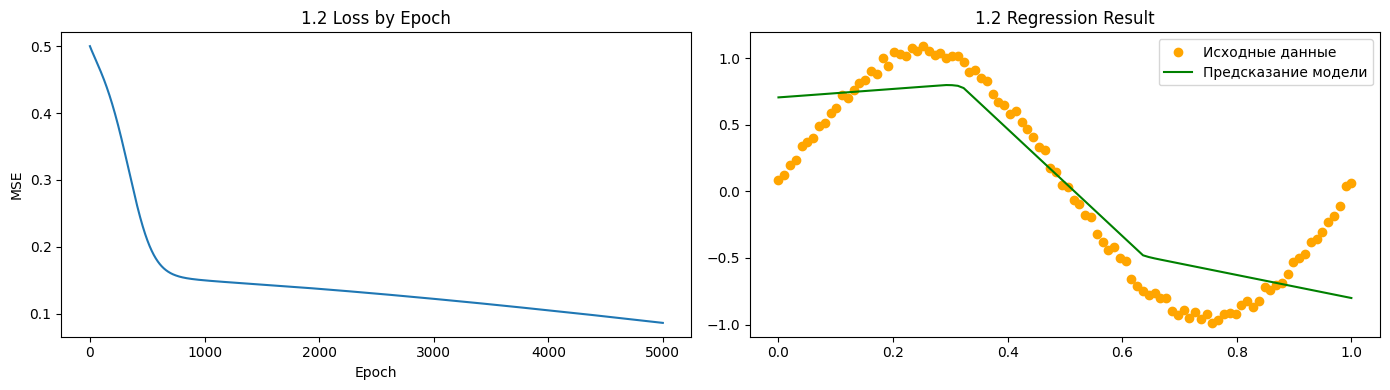

In [14]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.1 * torch.rand(X.size())

class Linear:
  def __init__(self, n_features, n_neurons):
    self.weights = (0.1 * torch.randn(n_features, n_neurons)).requires_grad_()
    self.biases = torch.zeros(1, n_neurons, requires_grad=True)

  def forward(self, inputs):
    return inputs @ self.weights + self.biases

  def parameters(self):
    return [self.weights, self.biases]

class ReLU:
  def forward(self, inputs):
    return torch.clamp(inputs, min=0)

class MSELoss:
  def forward(self, y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

fc1 = Linear(1, 64)
relu1 = ReLU()
fc2 = Linear(64, 64)
relu2 = ReLU()
fc3 = Linear(64, 1)
loss_fn = MSELoss()
learning_rate = 0.01
losses_12 = []

for epoch in range(5000):
  out1 = fc1.forward(X)
  out2 = relu1.forward(out1)
  out3 = fc2.forward(out2)
  out4 = relu2.forward(out3)
  y_pred = fc3.forward(out4)
  loss = loss_fn.forward(y_pred, y)
  losses_12.append(loss.item())

  loss.backward()
  with torch.no_grad():
    for param in fc1.parameters() + fc2.parameters() + fc3.parameters():
      param -= learning_rate * param.grad
      param.grad.zero_()

print('1.2 final loss:', losses_12[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses_12)
axes[0].set_title('1.2 Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[1].scatter(X.numpy(), y.numpy(), color='orange', label='Исходные данные')
axes[1].plot(X.numpy(), y_pred.detach().numpy(), color='green', label='Предсказание модели')
axes[1].set_title('1.2 Regression Result')
axes[1].legend()
plt.tight_layout()
plt.show()


## 2 Алгоритмы оптимизации в `torch.optim`


In [15]:
# 2.1 Решить задачу 1.1, воспользовавшись оптимизатором optim.SGD
X_sgd, y_sgd, _ = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X_sgd = torch.tensor(X_sgd, dtype=torch.float32)
y_sgd = torch.tensor(y_sgd, dtype=torch.float32)

class TorchNeuron(nn.Module):
  def __init__(self, n_inputs):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(n_inputs))
    self.bias = nn.Parameter(torch.randn(1))

  def forward(self, inputs):
    return inputs @ self.weights + self.bias

model_21 = TorchNeuron(X_sgd.shape[1])
optimizer_21 = optim.SGD(model_21.parameters(), lr=0.01)
losses_21 = []

for epoch in range(60):
  epoch_loss = 0.0
  for x_example, y_example in zip(X_sgd, y_sgd):
    optimizer_21.zero_grad()
    y_pred = model_21(x_example)
    loss = (y_pred - y_example) ** 2
    loss.backward()
    optimizer_21.step()
    epoch_loss += loss.item()
  losses_21.append(epoch_loss / len(X_sgd))

print('2.1 final loss:', losses_21[-1])


2.1 final loss: 7.430432180655089e-10


2.2 Решить задачу 1.2, воспользовавшись оптимизатором `optim.Adam` для применения пакетного градиетного спуска. Вывести график функции потерь в зависимости от номера эпохи. Вывести на одном графике исходные данные и предсказанные значения.


2.2 final loss: 0.0018010318744927645


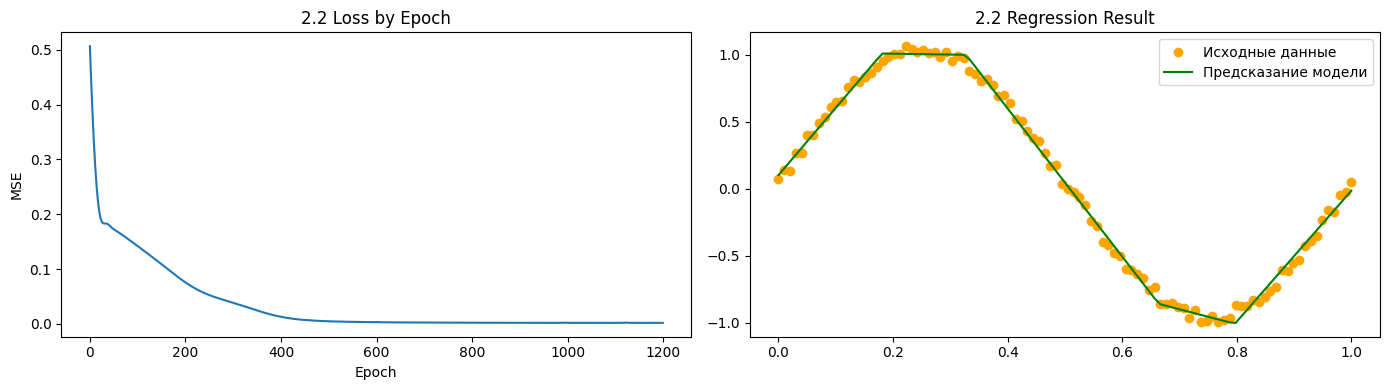

In [16]:
X_adam = torch.linspace(0, 1, 100).view(-1, 1)
y_adam = torch.sin(2 * np.pi * X_adam) + 0.1 * torch.rand(X_adam.size())

class RegressionNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
      nn.Linear(1, 32),
      nn.ReLU(),
      nn.Linear(32, 1)
    )

  def forward(self, x):
    return self.net(x)

model_22 = RegressionNet()
criterion_22 = nn.MSELoss()
optimizer_22 = optim.Adam(model_22.parameters(), lr=0.01)
losses_22 = []

for epoch in range(1200):
  optimizer_22.zero_grad()
  y_pred = model_22(X_adam)
  loss = criterion_22(y_pred, y_adam)
  loss.backward()
  optimizer_22.step()
  losses_22.append(loss.item())

print('2.2 final loss:', losses_22[-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(losses_22)
axes[0].set_title('2.2 Loss by Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[1].scatter(X_adam.numpy(), y_adam.numpy(), color='orange', label='Исходные данные')
axes[1].plot(X_adam.numpy(), model_22(X_adam).detach().numpy(), color='green', label='Предсказание модели')
axes[1].set_title('2.2 Regression Result')
axes[1].legend()
plt.tight_layout()
plt.show()


## 3 Построение сетей при помощи `torch.nn`
3.1 Решить задачу регрессии, соблюдая следующие условия:

1. Оформить нейронную сеть в виде класса - наследника `nn.Module`
2. При создании сети использовать готовые блоки из `torch.nn`: слои, функции активации, функции потерь и т.д.
3. Для оптимизации использовать любой алгоритм оптимизации из `torch.optim`


In [17]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.1 * torch.rand(X.size())

class SinRegressor(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(1, 32)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(32, 1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

model_31 = SinRegressor()
criterion_31 = nn.MSELoss()
optimizer_31 = optim.Adam(model_31.parameters(), lr=0.01)
losses_31 = []

for epoch in range(1000):
  optimizer_31.zero_grad()
  pred = model_31(X)
  loss = criterion_31(pred, y)
  loss.backward()
  optimizer_31.step()
  losses_31.append(loss.item())

print('3.1 final loss:', losses_31[-1])


3.1 final loss: 0.0014043350238353014


3.2 Решить задачу регрессии, соблюдая следующие условия:

1. Оформить нейронную сеть в виде объекта `nn.Sequential`
2. При создании сети использовать готовые блоки из `torch.nn`: слои, функции активации, функции потерь и т.д.
3. Для оптимизации использовать любой алгоритм оптимизации из `torch.optim`


In [ ]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * np.pi * X) + 0.1 * torch.rand(X.size())

model_32 = nn.Sequential(
  nn.Linear(1, 32),
  nn.Tanh(),
  nn.Linear(32, 16),
  nn.ReLU(),
  nn.Linear(16, 1)
)

criterion_32 = nn.MSELoss()
optimizer_32 = optim.Adam(model_32.parameters(), lr=0.01)
losses_32 = []

for epoch in range(1000):
  optimizer_32.zero_grad()
  pred = model_32(X)
  loss = criterion_32(pred, y)
  loss.backward()
  optimizer_32.step()
  losses_32.append(loss.item())

print('3.2 final loss:', losses_32[-1])


3.2 final loss: 0.0012126383371651173


## 4. Datasets and dataloaders


In [19]:
class SinDataset(Dataset):
  def __init__(self):
    self.X = torch.linspace(0, 1, 100).view(-1, 1)
    self.y = torch.sin(2 * np.pi * self.X) + 0.1 * torch.rand(self.X.size())

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

sin_dataset = SinDataset()
sin_loader = DataLoader(sin_dataset, batch_size=10, shuffle=True)

batch_X, batch_y = next(iter(sin_loader))
print('4.1 first batch shapes:', batch_X.shape, batch_y.shape)

model_41 = SinRegressor()
criterion_41 = nn.MSELoss()
optimizer_41 = optim.Adam(model_41.parameters(), lr=0.01)
losses_41 = []

for epoch in range(300):
  batch_losses = []
  for X_batch, y_batch in sin_loader:
    optimizer_41.zero_grad()
    pred = model_41(X_batch)
    loss = criterion_41(pred, y_batch)
    loss.backward()
    optimizer_41.step()
    batch_losses.append(loss.item())
  losses_41.append(sum(batch_losses) / len(batch_losses))

print('4.1 final loss:', losses_41[-1])


4.1 first batch shapes: torch.Size([10, 1]) torch.Size([10, 1])
4.1 final loss: 0.003928089397959411


4.2 Предсказание цен алмазов

4.2.1 Создайте датасет на основе файла diamonds.csv.

1. Удалите все нечисловые столбцы
2. Целевой столбец (`y`) - `price`
3. Преобразуйте данные в тензоры корректных размеров

4.2.2 Разбейте датасет на обучающий и тестовый датасет при помощи `torch.utils.data.random_split`.

4.2.3 Обучите модель для предсказания цен при помощи мини-пакетного градиентного спуска (`batch_size = 256`).

4.2.4 Выведите график функции потерь в зависимости от номера эпохи (значение потерь для эпохи рассчитывайте как среднее значение ошибок на каждом батче). Проверьте качество модели на тестовой выборке.


4.2 test MSE (normalized target): 0.12335849691962086
4.2 test MAE (normalized target): 0.19519983128059742
4.2 test MAE (price units): 778.7307597228375


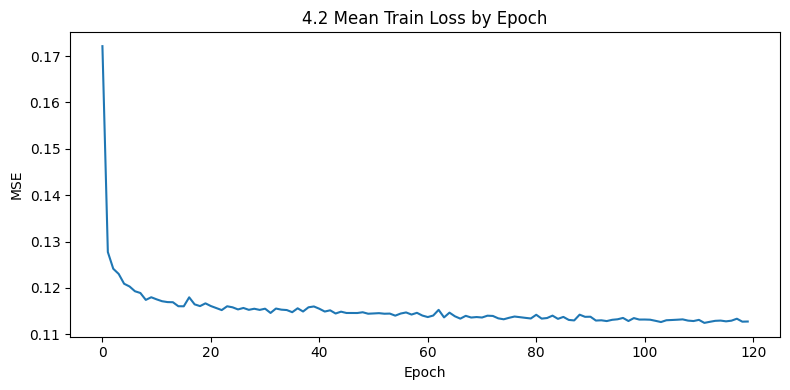

In [20]:
class DiamondsDataset(Dataset):
  def __init__(self, data):
    numeric = data.select_dtypes(include=[np.number]).copy()
    if 'Unnamed: 0' in numeric.columns:
      numeric = numeric.drop(columns=['Unnamed: 0'])

    X_np = numeric.drop(columns=['price']).to_numpy(dtype=np.float32)
    y_np = numeric['price'].to_numpy(dtype=np.float32).reshape(-1, 1)

    self.X_mean = torch.tensor(X_np.mean(axis=0, keepdims=True), dtype=torch.float32)
    self.X_std = torch.tensor(X_np.std(axis=0, keepdims=True) + 1e-8, dtype=torch.float32)
    self.y_mean = torch.tensor(y_np.mean(axis=0, keepdims=True), dtype=torch.float32)
    self.y_std = torch.tensor(y_np.std(axis=0, keepdims=True) + 1e-8, dtype=torch.float32)

    self.X = (torch.tensor(X_np, dtype=torch.float32) - self.X_mean) / self.X_std
    self.y = (torch.tensor(y_np, dtype=torch.float32) - self.y_mean) / self.y_std

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

data = pd.read_csv('diamonds.csv')
diamonds_dataset = DiamondsDataset(data)

train_size = int(0.8 * len(diamonds_dataset))
test_size = len(diamonds_dataset) - train_size
train_dataset, test_dataset = random_split(diamonds_dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

model_42 = nn.Sequential(
  nn.Linear(diamonds_dataset.X.shape[1], 64),
  nn.ReLU(),
  nn.Linear(64, 32),
  nn.ReLU(),
  nn.Linear(32, 1)
)

criterion_42 = nn.MSELoss()
optimizer_42 = optim.Adam(model_42.parameters(), lr=0.003)
losses_42 = []

for epoch in range(120):
  model_42.train()
  batch_losses = []
  for X_batch, y_batch in train_loader:
    optimizer_42.zero_grad()
    pred = model_42(X_batch)
    loss = criterion_42(pred, y_batch)
    loss.backward()
    optimizer_42.step()
    batch_losses.append(loss.item())
  losses_42.append(sum(batch_losses) / len(batch_losses))

model_42.eval()
test_losses = []
abs_errors = []
with torch.no_grad():
  for X_batch, y_batch in test_loader:
    pred = model_42(X_batch)
    test_losses.append(criterion_42(pred, y_batch).item())
    abs_errors.append(torch.mean(torch.abs(pred - y_batch)).item())

test_mse = sum(test_losses) / len(test_losses)
test_mae_norm = sum(abs_errors) / len(abs_errors)
test_mae_price = test_mae_norm * diamonds_dataset.y_std.item()
print('4.2 test MSE (normalized target):', test_mse)
print('4.2 test MAE (normalized target):', test_mae_norm)
print('4.2 test MAE (price units):', test_mae_price)

plt.figure(figsize=(8, 4))
plt.plot(losses_42)
plt.title('4.2 Mean Train Loss by Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()


4.3 Модифицируйте метод `__init__` датасета из 4.2 таким образом, чтобы он мог принимать параметр `transform: callable`. Реализуйте класс `DropColsTransform` для удаления нечисловых данных из массива. Реализуйте класс `ToTensorTransorm` для трансформации массива в тензор.


In [21]:
class DiamondsDataset(Dataset):
  def __init__(self, data, transform=None):
    self.transform = transform
    raw = data.copy()
    if 'Unnamed: 0' in raw.columns:
      raw = raw.drop(columns=['Unnamed: 0'])

    self.y = raw['price'].to_numpy(dtype=np.float32)
    self.X = raw.drop(columns=['price']).reset_index(drop=True)
    self.feature_names = list(self.X.columns)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    sample = self.X.iloc[idx].copy(), self.y[idx]
    if self.transform:
      sample = self.transform(sample)
    return sample

class DropColsTransform:
  def __init__(self, drop):
    self.drop = drop

  def __call__(self, sample):
    X, y = sample
    if hasattr(X, 'select_dtypes'):
      X = X.drop(labels=self.drop)
      X = X.to_numpy(dtype=np.float32)
    elif hasattr(X, 'drop'):
      X = X.drop(labels=self.drop)
      X = pd.to_numeric(X, errors='coerce').to_numpy(dtype=np.float32)
    else:
      X = np.asarray(X)
      if X.dtype == object:
        keep_mask = np.array([i not in self.drop for i in range(len(X))])
        X = X[keep_mask]
      X = X.astype(np.float32)
    return X, y

class ToTensorTransform:
  def __call__(self, sample):
    X, y = sample
    X = np.asarray(X, dtype=np.float32)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor([y], dtype=torch.float32)
    return X, y

class Compose:
  def __init__(self, transforms):
    self.transforms = transforms

  def __call__(self, sample):
    for transform in self.transforms:
      sample = transform(sample)
    return sample


In [22]:
data = pd.read_csv('diamonds.csv')
raw_feature_names = [col for col in data.columns if col not in ['Unnamed: 0', 'price']]
non_numeric_cols = [col for col in raw_feature_names if data[col].dtype == object]

transform = Compose([
  DropColsTransform(drop=non_numeric_cols),
  ToTensorTransform()
])

dataset = DiamondsDataset(data, transform=transform)
X_sample, y_sample = dataset[0]
print('4.3 sample feature tensor shape:', X_sample.shape)
print('4.3 sample target tensor shape:', y_sample.shape)
print('4.3 non-numeric columns:', non_numeric_cols)


4.3 sample feature tensor shape: torch.Size([9])
4.3 sample target tensor shape: torch.Size([1])
4.3 non-numeric columns: []
